## (0) Settings and Functions

In [1]:
%load_ext autotime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import make_scorer, hamming_loss

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

time: 2.44 s (started: 2026-02-18 16:35:32 -03:00)


In [7]:
df = pd.read_csv("../../data/feat/go_emotions_with_features.csv")

print(df.shape)
df.head(3)

(54234, 56)


,UNCLEAN_TEXT_PT,BASE_TEXT_PT,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,punctuation_per_word,exclamation_per_word,question_per_word,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,uppercase_percentage,mean_unique_word_length,mean_char_repetition_per_word
0,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,0,0,0,0,1,0,0,0,...,0.142857,0.0,0.0,0.095238,0.047619,0.5,77.937143,0.073684,4.388889,0.0
1,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,0,0,0,0,0,0,0,0,...,0.222222,0.0,0.0,0.222222,0.000000,0.0,61.320000,0.045455,4.833333,0.0
2,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,0,0,0,0,0,0,0,0,...,0.333333,0.0,0.0,0.125000,0.062500,0.5,72.640000,0.134831,4.666667,0.0


time: 818 ms (started: 2026-02-18 16:44:03 -03:00)


In [3]:
def evaluate_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    hamming_scorer = make_scorer(
        hamming_loss,
        greater_is_better=False
    )

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        'f1_micro': 'f1_micro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'hamming_loss': hamming_scorer
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_macro_scores = results['test_f1_macro']
    f1_weighted_scores = results['test_f1_weighted']
    f1_micro_scores = results['test_f1_micro']
    hamming_scores = results['test_hamming_loss']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_macro_scores.mean(),   f1_macro_scores.std(),   f1_macro_scores),
        "F1_weighted":   (f1_weighted_scores.mean(),   f1_weighted_scores.std(),   f1_weighted_scores),
        "F1_micro":   (f1_micro_scores.mean(),   f1_micro_scores.std(),   f1_micro_scores),
        "Hamming_loss":   (-hamming_scores.mean(),   hamming_scores.std(),   hamming_scores),
    }

def plot_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    if not hasattr(model, "feature_importances_"):
        raise ValueError("Model does not expose feature_importances_")
    
    importances = model.feature_importances_

    if importances.ndim == 2:
        importances = importances.mean(axis=0)

    idx_sorted = np.argsort(importances)[::-1][:k]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(k), importances[idx_sorted][::-1])
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances (avg) - {model_name}")
    plt.xlabel("Mean Importance across labels")
    plt.tight_layout()
    plt.show()

time: 2.59 ms (started: 2026-02-18 16:35:39 -03:00)


## (1) Predict Baseline PT

In [9]:
df['BASE_TEXT_PT'] = (
    df['BASE_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = ['BASE_TEXT_PT'] + numerical_features

X = df[cols_input]
y = df[emotion_cols].values

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_train.shape, X_dev.shape, X_test.shape)

(37963, 17) (8135, 17) (8136, 17)
time: 52.4 ms (started: 2026-02-18 16:44:52 -03:00)


In [10]:
models_for_testing = {
    "LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    # "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": OneVsRestClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            verbosity=0
    ))
}

results = []

def run_predictions(name, model, X_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    preprocessor = ColumnTransformer(
        transformers=[
            ('bow', CountVectorizer(), 'BASE_TEXT_PT'),
            ('scaler', StandardScaler(), numerical_features)
        ],
        remainder='drop'
    )

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_res = evaluate_cv(clone(pipe), X_train, y_train, n_splits=5, n_repeats=6)

    # plot_learning_curve(clone(pipe), X_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],

        "CV_F1_micro_mean":  cv_res["F1_micro"][0],
        "CV_F1_micro_std":   cv_res["F1_micro"][1],
        "CV_F1_micro_all":   cv_res["F1_micro"][2],

        "CV_Hamming_loss_mean":  cv_res["Hamming_loss"][0],
        "CV_Hamming_loss_std":   cv_res["Hamming_loss"][1],
        "CV_Hamming_loss_all":   cv_res["Hamming_loss"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_train, y_train)


Running model: LogisticRegression

Running model: RidgeClassifier

Running model: LinearSVC


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-d


Running model: XGBClassifier
time: 43min 17s (started: 2026-02-18 16:45:00 -03:00)


In [11]:
df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

Best model: LinearSVC
time: 3.36 ms (started: 2026-02-18 17:30:04 -03:00)


In [12]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted", "F1_micro", "Hamming_loss"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/feat/feat_05_GoEmotions_BoW.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,F1_micro,Hamming_loss
LogisticRegression,0.304 ± 0.0051,0.5342 ± 0.0258,0.2172 ± 0.0059,0.2853 ± 0.0086,0.4044 ± 0.0059,0.443 ± 0.005,0.0357 ± 0.0003
RidgeClassifier,0.2839 ± 0.0056,0.5152 ± 0.0201,0.2493 ± 0.0073,0.3109 ± 0.0082,0.3933 ± 0.0061,0.4322 ± 0.0055,0.0372 ± 0.0004
LinearSVC,0.2952 ± 0.0039,0.4233 ± 0.0133,0.2819 ± 0.0051,0.3302 ± 0.0058,0.4227 ± 0.0049,0.4411 ± 0.0043,0.0411 ± 0.0003
XGBClassifier,0.2615 ± 0.0061,0.5642 ± 0.0235,0.2283 ± 0.0058,0.2987 ± 0.0079,0.3761 ± 0.0071,0.4108 ± 0.0069,0.0358 ± 0.0004


time: 113 ms (started: 2026-02-18 17:30:07 -03:00)


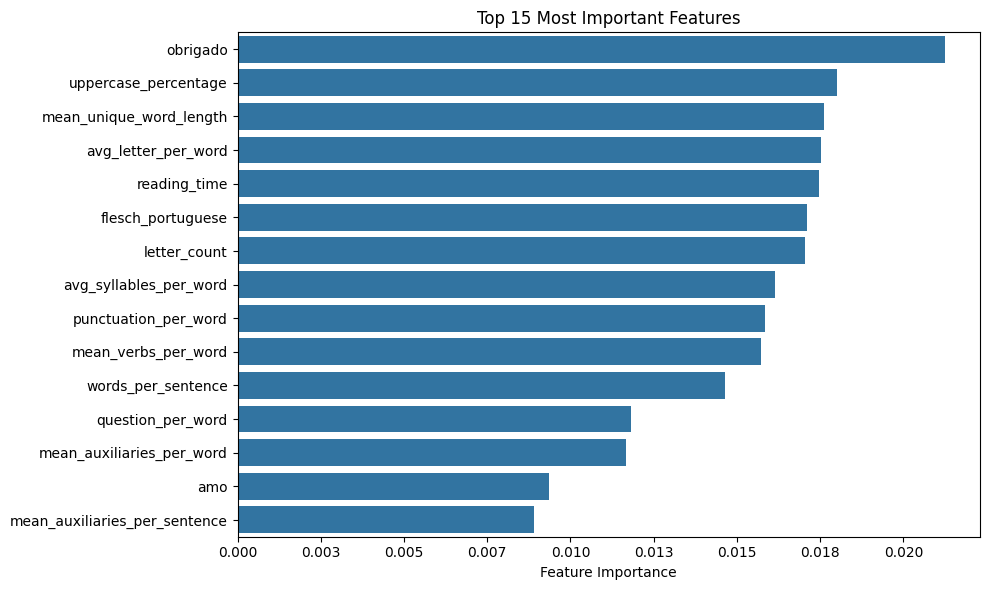

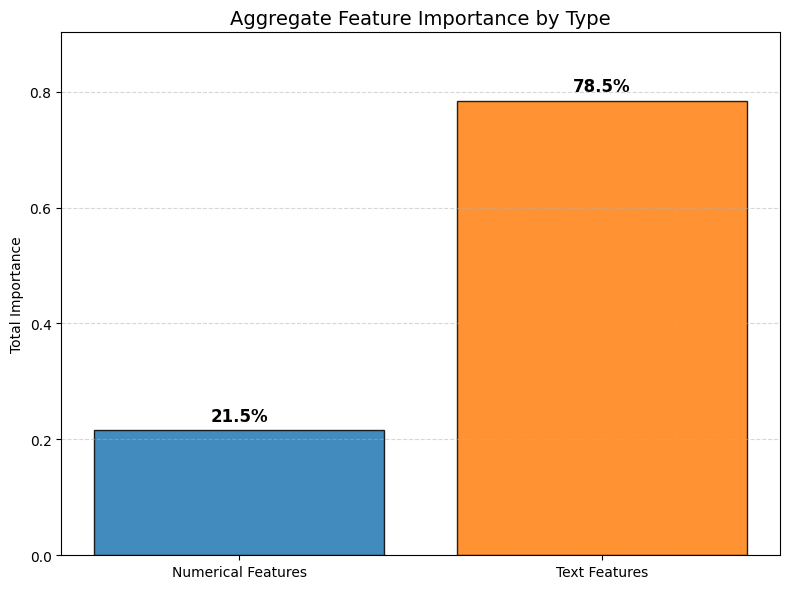

time: 3min 35s (started: 2026-02-18 17:32:41 -03:00)


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ('bow', CountVectorizer(), 'BASE_TEXT_PT'),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

preprocessor = pipe_rf.named_steps["preprocessor"]
model = pipe_rf.named_steps["model"]

bow = preprocessor.named_transformers_["bow"]
bow_features = bow.get_feature_names_out()

num_features = numerical_features

all_feature_names = np.concatenate([
    bow_features,
    num_features
])

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top15 = feat_imp.head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top15,
    x="importance",
    y="feature",
)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.3f}")
plt.title("Top 15 Most Important Features", fontsize=12)
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

bow_set = set(bow_features)
feat_imp["type"] = feat_imp["feature"].apply(
    lambda f: "Text Features" if f in bow_set else "Numerical Features"
)

agg_imp = (
    feat_imp
    .groupby("type")["importance"]
    .sum()
    .reset_index()
)
agg_imp["percentage"] = (
    agg_imp["importance"] / agg_imp["importance"].sum()
)

plt.figure(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e'] 
bars = plt.bar(
    agg_imp["type"],
    agg_imp["importance"],
    color=colors,
    alpha=0.85,
    edgecolor="black"
)

for bar, perc in zip(bars, agg_imp["percentage"]):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{perc:.1%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Aggregate Feature Importance by Type", fontsize=14)
plt.ylabel("Total Importance")
plt.xlabel("")
plt.ylim(0, agg_imp["importance"].max() * 1.15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
rows = []

for _, row in df_results.iterrows():
    model = row["Model"]
    for score in row["CV_F1_macro_all"]:
        rows.append({
            "Model": model,
            "F1_macro": score
        })

df_long = pd.DataFrame(rows)

df_pivot = df_long.pivot_table(
    index=df_long.groupby("Model").cumcount(),
    columns="Model",
    values="F1_macro"
)

stat, p_value = friedmanchisquare(
    *[df_pivot[col].values for col in df_pivot.columns]
)

print(f"Friedman chi2 = {stat:.4f}") # p >= 0.05 -> there is no overall statistical difference                    
print(f"p-value = {p_value:.6f}") # p < 0.05 -> at least one model is statistically different

alpha = 0.05
results_wilcoxon = []

models = df_pivot.columns.tolist()

for m1, m2 in itertools.combinations(models, 2):
    stat, p = wilcoxon(df_pivot[m1], df_pivot[m2])
    results_wilcoxon.append({
        "Model_1": m1,
        "Model_2": m2,
        "p_value": p,
    })

df_wilcoxon = pd.DataFrame(results_wilcoxon)

df_wilcoxon["p_corrected"] = multipletests(
    df_wilcoxon["p_value"],
    method="holm"
)[1]

df_wilcoxon["Significant"] = df_wilcoxon["p_corrected"] < alpha

df_wilcoxon.style.hide(axis="index")

Friedman chi2 = 84.5200
p-value = 0.000000


Model_1,Model_2,p_value,p_corrected,Significant
LinearSVC,LogisticRegression,0.000000,0.000000,True
LinearSVC,RidgeClassifier,0.000000,0.000000,True
LinearSVC,XGBClassifier,0.000000,0.000000,True
LogisticRegression,RidgeClassifier,0.000000,0.000000,True
LogisticRegression,XGBClassifier,0.000000,0.000000,True
RidgeClassifier,XGBClassifier,0.000000,0.000000,True


time: 183 ms (started: 2026-02-18 17:36:17 -03:00)


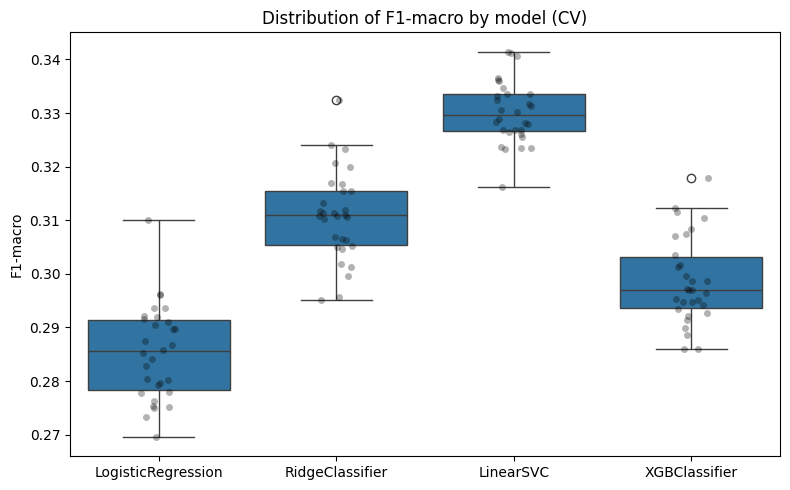

time: 141 ms (started: 2026-02-18 17:36:17 -03:00)


In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_long,
    x="Model",
    y="F1_macro"
)
sns.stripplot(
    data=df_long,
    x="Model",
    y="F1_macro",
    color="black",
    alpha=0.3
)

plt.title("Distribution of F1-macro by model (CV)")
plt.ylabel("F1-macro")
plt.xlabel("")
plt.tight_layout()
plt.show()